# Notebook 01 — Exploration (Kaggle Edition)

## Personalized News Recommendation System — Official MINDsmall Train/Dev Split

This notebook is **EDA only**: no embeddings, no FAISS, no model training, no evaluation.
It runs top-to-bottom in a fresh Kaggle session with three attached datasets:

1. `MINDsmall_train` — official MIND training split
2. `MINDsmall_dev` — official MIND dev split
3. `personalized-news-recommender` — this project's source code

All three are located deterministically by walking `/kaggle/input` for their exact
nested directory names — no dependency on any third-party MIND mirror dataset.

## 0. Kaggle Environment Setup

In [6]:
import os
from pathlib import Path

def resolve_kaggle_datasets():
    """
    Deterministically locate the three separately-attached Kaggle datasets by
    walking /kaggle/input and matching on the exact nested directory name
    (MINDsmall_train, MINDsmall_dev, personalized-news-recommender), verifying
    real files with Path.is_file(). This does NOT do broad recursive
    train/dev guessing across arbitrary datasets -- it only normalizes for
    Kaggle's mount-slug naming.
    """
    input_root = Path("/kaggle/input")
    if not input_root.exists():
        raise RuntimeError("/kaggle/input does not exist -- are you running on Kaggle?")

    train_matches, dev_matches, project_matches = [], [], []

    for top in input_root.iterdir():
        if not top.is_dir():
            continue
        for root, dirs, files in os.walk(top):
            root_path = Path(root)
            name = root_path.name

            if name == "MINDsmall_train":
                if (root_path / "news.tsv").is_file() and (root_path / "behaviors.tsv").is_file():
                    train_matches.append(root_path)

            elif name == "MINDsmall_dev":
                if (root_path / "news.tsv").is_file() and (root_path / "behaviors.tsv").is_file():
                    dev_matches.append(root_path)

            elif name == "personalized-news-recommender":
                if (root_path / "src").is_dir() and (root_path / "requirements.txt").is_file():
                    project_matches.append(root_path)

    top_level_dirs = [str(p) for p in input_root.iterdir() if p.is_dir()]

    problems = []
    if len(train_matches) == 0:
        problems.append("No real 'MINDsmall_train' directory (with news.tsv + behaviors.tsv) found.")
    elif len(train_matches) > 1:
        problems.append(f"Found {len(train_matches)} candidate MINDsmall_train directories: {train_matches}")

    if len(dev_matches) == 0:
        problems.append("No real 'MINDsmall_dev' directory (with news.tsv + behaviors.tsv) found.")
    elif len(dev_matches) > 1:
        problems.append(f"Found {len(dev_matches)} candidate MINDsmall_dev directories: {dev_matches}")

    if len(project_matches) == 0:
        problems.append("No real 'personalized-news-recommender' project directory (with src/) found.")
    elif len(project_matches) > 1:
        problems.append(f"Found {len(project_matches)} candidate project directories: {project_matches}")

    if problems:
        raise RuntimeError(
            "Could not deterministically resolve the required Kaggle datasets.\n"
            + "\n".join(problems)
            + f"\n\nTop-level directories under /kaggle/input: {top_level_dirs}\n"
            "Attach the 'MINDsmall_train', 'MINDsmall_dev', and "
            "'personalized-news-recommender' Kaggle datasets to this notebook."
        )

    train_source, dev_source, project_source = train_matches[0], dev_matches[0], project_matches[0]
    assert train_source != dev_source, "TRAIN_SOURCE and DEV_SOURCE resolved to the same directory."

    for f in (train_source / "news.tsv", train_source / "behaviors.tsv",
              dev_source / "news.tsv", dev_source / "behaviors.tsv"):
        assert f.is_file() and f.stat().st_size > 0, f"Not a real, non-empty file: {f}"

    return train_source, dev_source, project_source


TRAIN_SOURCE, DEV_SOURCE, PROJECT_SOURCE = resolve_kaggle_datasets()
print("TRAIN_SOURCE:  ", TRAIN_SOURCE)
print("DEV_SOURCE:    ", DEV_SOURCE)
print("PROJECT_SOURCE:", PROJECT_SOURCE)


TRAIN_SOURCE:   /kaggle/input/datasets/timepassforme01/mindsmall-train/MINDsmall_train
DEV_SOURCE:     /kaggle/input/datasets/timepassforme01/mindsmall-dev/MINDsmall_dev
PROJECT_SOURCE: /kaggle/input/datasets/timepassforme01/personalized-news-recommender/personalized-news-recommender


In [7]:
# Copy the read-only project source into a writable working copy
import shutil
import sys

PROJECT_ROOT = Path("/kaggle/working/personalized-news-recommender")

if PROJECT_ROOT.exists():
    shutil.rmtree(PROJECT_ROOT)  # Notebook 01 does not train anything -- safe to start fresh
shutil.copytree(PROJECT_SOURCE, PROJECT_ROOT)
assert (PROJECT_ROOT / "src" / "config.py").exists()

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) in sys.path:
    sys.path.remove(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT))

for mod_name in list(sys.modules):
    if mod_name == "src" or mod_name.startswith("src."):
        del sys.modules[mod_name]

from src import config

print("PROJECT_ROOT:", PROJECT_ROOT)
print("config loaded from:", config.__file__)
assert str(config.__file__).startswith(str(PROJECT_ROOT)), "config imported from an unexpected location"


PROJECT_ROOT: /kaggle/working/personalized-news-recommender
config loaded from: /kaggle/working/personalized-news-recommender/src/config.py


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.preprocess import load_news, load_behaviors

pd.set_option("display.max_colwidth", 80)
print("Imports OK.")

Imports OK.


## 1. Dataset Overview

Loaded directly from `TRAIN_SOURCE` — no copying into the project's `dataset/` folder
is needed for pure exploration.

In [9]:
news = load_news(TRAIN_SOURCE / "news.tsv")
behaviors = load_behaviors(TRAIN_SOURCE / "behaviors.tsv")

print("News columns:     ", list(news.columns))
print("Behavior columns: ", list(behaviors.columns))
print()
print("News shape:      ", news.shape)
print("Behaviors shape: ", behaviors.shape)
print("Unique NewsID:   ", news["NewsID"].nunique())
print("Unique UserID:   ", behaviors["UserID"].nunique())
print("Impression rows: ", len(behaviors))

2026-07-13 19:55:35 | INFO     | news_recommender | Loaded news file: /kaggle/input/datasets/timepassforme01/mindsmall-train/MINDsmall_train/news.tsv -> (51282, 8)
2026-07-13 19:55:36 | INFO     | news_recommender | Loaded behaviors file: /kaggle/input/datasets/timepassforme01/mindsmall-train/MINDsmall_train/behaviors.tsv -> (156965, 5)


News columns:      ['NewsID', 'Category', 'SubCategory', 'Title', 'Abstract', 'URL', 'TitleEntities', 'AbstractEntities']
Behavior columns:  ['ImpressionID', 'UserID', 'Time', 'History', 'Impressions']

News shape:       (51282, 8)
Behaviors shape:  (156965, 5)
Unique NewsID:    51282
Unique UserID:    50000
Impression rows:  156965


In [10]:
news.head()

,NewsID,Category,SubCategory,Title,Abstract,URL,TitleEntities,AbstractEntities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, and Prince Philip Swear By","Shop the notebooks, jackets, and more that the royals can't live without.",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"", ""Type"": ""P"", ""WikidataId"": ""Q...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding you back and keeping you from sh...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""WikidataId"": ""Q193583"", ""Confiden...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""WikidataId"": ""Q193583"", ""Confiden..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches of Ukraine's War,Lt. Ivan Molchanets peeked over a parapet of sand bags at the front line of ...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId"": ""Q212"", ""Confidence"": 0.946..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My Mental Health.,"I felt like I was a fraud, and being an NBA wife didn't help that. In fact, ...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ""Type"": ""O"", ""WikidataId"": ""Q1..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a Dermatologist","They seem harmless, but there's a very good reason you shouldn't ignore them...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataId"": ""Q3179593"", ""Confidence"": ...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataId"": ""Q3179593"", ""Confidence"": ..."


In [11]:
behaviors.head()

,ImpressionID,UserID,Time,History,Impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N10414 N19347 N31801,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129 N1569 N17686 N13008 N21623 N6...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N22407-0 N14592-0 N17059-1 N336...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384 N46616 N52500 N33164 N47289 N...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N59685-0 N23814-1 N23446-0 N641...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 N29757 N31825 N51891,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N60408-0 N61497-0 N47412-0 N4122...


**Observation:** The raw schemas match the official MIND format
(`NewsID, Category, SubCategory, Title, Abstract, URL, TitleEntities, AbstractEntities`
for news; `ImpressionID, UserID, Time, History, Impressions` for behaviors).

## 2. Data Quality Analysis

Impression tokens are parsed with `rsplit("-", 1)` (splitting from the right on the last
hyphen) rather than a naive `split("-")`, since this is the parsing convention used
consistently across `src/ranker.py` and `src/ranking.py`.

In [12]:
print("Missing values (news):")
print(news.isnull().sum())
print()
print("Missing values (behaviors):")
print(behaviors.isnull().sum())

Missing values (news):
NewsID                 0
Category               0
SubCategory            0
Title                  0
Abstract            2666
URL                    0
TitleEntities          3
AbstractEntities       4
dtype: int64

Missing values (behaviors):
ImpressionID       0
UserID             0
Time               0
History         3238
Impressions        0
dtype: int64


In [13]:
dup_news = news["NewsID"].duplicated().sum()
dup_behaviors = behaviors.duplicated().sum()
empty_history = (behaviors["History"].isnull() | (behaviors["History"] == "")).sum()

print(f"Duplicate NewsIDs:        {dup_news}")
print(f"Duplicate behavior rows:  {dup_behaviors}")
print(f"Empty-history rows:       {empty_history} ({empty_history / len(behaviors):.1%})")

Duplicate NewsIDs:        0
Duplicate behavior rows:  0
Empty-history rows:       3238 (2.1%)


In [14]:
def parse_impression_tokens(impressions_str):
    """Parse 'N123-1 N456-0' into [(NewsID, label), ...] using rsplit for safety."""
    pairs = []
    for token in str(impressions_str).split():
        try:
            news_id, label = token.rsplit("-", 1)
        except ValueError:
            continue
        pairs.append((news_id, label))
    return pairs

malformed_count = 0
label_counts = {"0": 0, "1": 0, "other": 0}

sample_behaviors = behaviors.sample(n=min(20000, len(behaviors)), random_state=config.RANDOM_SEED)
for impressions in sample_behaviors["Impressions"].dropna():
    raw_tokens = impressions.split()
    parsed = parse_impression_tokens(impressions)
    malformed_count += len(raw_tokens) - len(parsed)
    for _, label in parsed:
        if label in ("0", "1"):
            label_counts[label] += 1
        else:
            label_counts["other"] += 1

print(f"Malformed impression tokens (sample of {len(sample_behaviors)} rows): {malformed_count}")
print("Label distribution (sample):", label_counts)
assert label_counts["other"] == 0, "Found impression labels outside {0, 1}."
print("\nAll parsed labels are valid (0 or 1).")

Malformed impression tokens (sample of 20000 rows): 0
Label distribution (sample): {'0': 712053, '1': 30227, 'other': 0}

All parsed labels are valid (0 or 1).


**Observation:** The dataset is essentially complete (news/behaviors have minimal
missing fields), NewsIDs are unique, and impression labels are cleanly binary once parsed
correctly with `rsplit`.

## 3. News Category Analysis

In [15]:
top_categories = news["Category"].value_counts()
top_subcategories = news["SubCategory"].value_counts()

print("Top 10 categories:")
print(top_categories.head(10))
print()
print("Top 10 subcategories:")
print(top_subcategories.head(10))

Top 10 categories:
Category
news            15774
sports          14510
finance          3107
foodanddrink     2551
lifestyle        2479
travel           2350
video            2068
weather          2048
health           1885
autos            1639
Name: count, dtype: int64

Top 10 subcategories:
SubCategory
newsus                      6564
football_nfl                5420
newspolitics                2826
newscrime                   2254
weathertopstories           2047
newsworld                   1720
football_ncaa               1665
baseball_mlb                1661
basketball_nba              1555
newsscienceandtechnology    1210
Name: count, dtype: int64


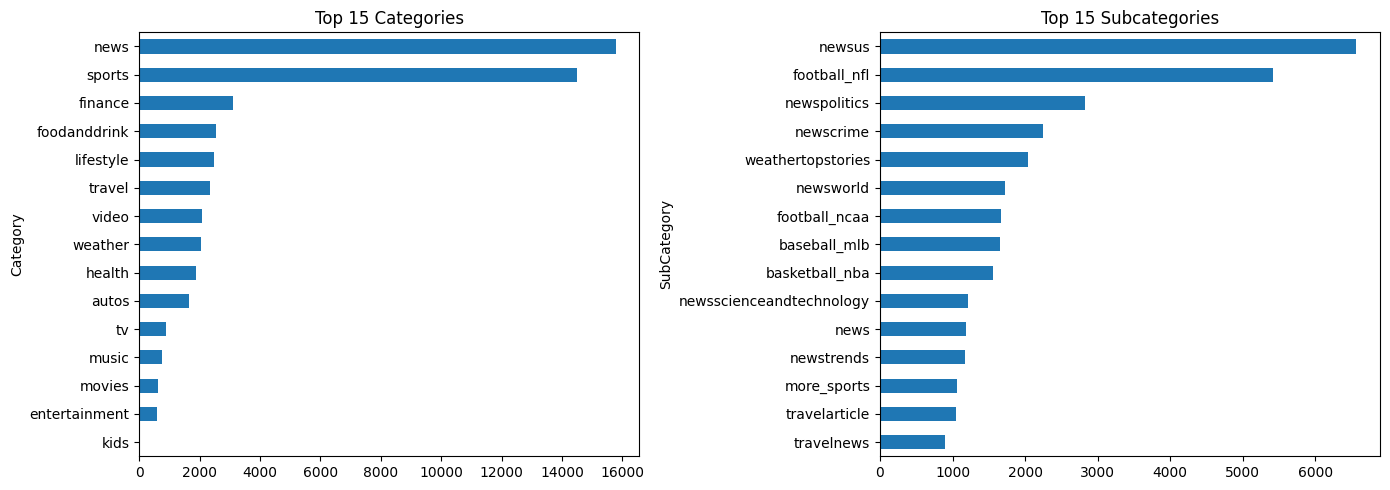

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_categories.head(15).plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 15 Categories")
axes[0].invert_yaxis()

top_subcategories.head(15).plot(kind="barh", ax=axes[1])
axes[1].set_title("Top 15 Subcategories")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 4. News Text Analysis

In [17]:
title_lengths = news["Title"].fillna("").str.split().apply(len)
abstract_lengths = news["Abstract"].fillna("").str.split().apply(len)
missing_abstracts = (news["Abstract"].isnull() | (news["Abstract"] == "")).sum()

print(f"Missing/empty abstracts: {missing_abstracts} ({missing_abstracts / len(news):.1%})")
print()
print("Title word-count stats:")
print(title_lengths.describe())
print()
print("Abstract word-count stats:")
print(abstract_lengths.describe())

Missing/empty abstracts: 2666 (5.2%)

Title word-count stats:
count    51282.000000
mean        10.754417
std          3.265311
min          1.000000
25%          9.000000
50%         10.000000
75%         13.000000
max         57.000000
Name: Title, dtype: float64

Abstract word-count stats:
count    51282.000000
mean        34.293319
std         26.542819
min          0.000000
25%         15.000000
50%         24.000000
75%         62.000000
max        474.000000
Name: Abstract, dtype: float64


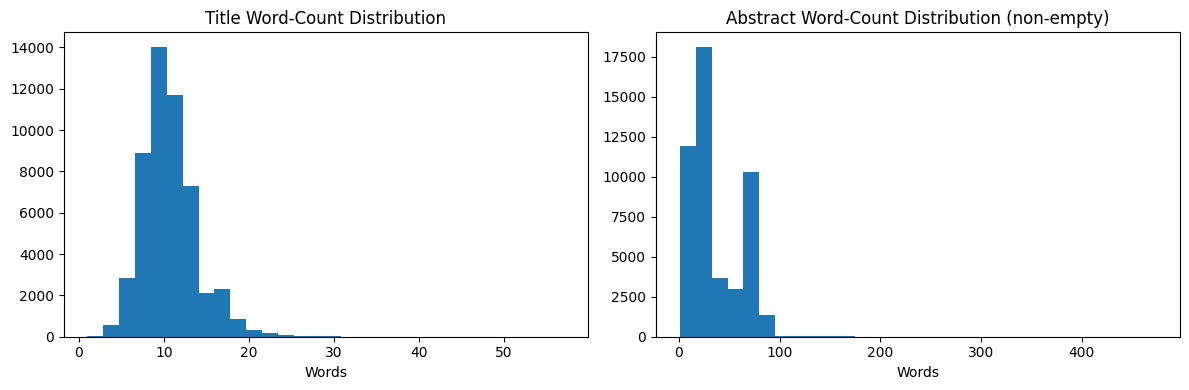

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(title_lengths, bins=30)
axes[0].set_title("Title Word-Count Distribution")
axes[0].set_xlabel("Words")

axes[1].hist(abstract_lengths[abstract_lengths > 0], bins=30)
axes[1].set_title("Abstract Word-Count Distribution (non-empty)")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()

**Observation:** A meaningful share of articles have short or missing abstracts,
which is why the project's text field combines Category + SubCategory + Title + Abstract
rather than relying on the abstract alone.

## 5. User History Analysis

Behavior rows are impressions, not unique users — a single user can appear in many
impression rows. The two are reported separately below.

In [19]:
history_lengths = behaviors["History"].fillna("").apply(lambda s: len(s.split()) if s else 0)

n_rows = len(behaviors)
n_unique_users = behaviors["UserID"].nunique()
n_warm_rows = int((history_lengths > 0).sum())
n_cold_rows = n_rows - n_warm_rows

print(f"Behavior rows (impressions): {n_rows:,}")
print(f"Unique users:                {n_unique_users:,}")
print(f"Rows with usable history (warm): {n_warm_rows:,} ({n_warm_rows / n_rows:.1%})")
print(f"Rows with no history (cold):     {n_cold_rows:,} ({n_cold_rows / n_rows:.1%})")
print()
print("History-length stats (warm rows only):")
print(history_lengths[history_lengths > 0].describe())

Behavior rows (impressions): 156,965
Unique users:                50,000
Rows with usable history (warm): 153,727 (97.9%)
Rows with no history (cold):     3,238 (2.1%)

History-length stats (warm rows only):
count    153727.000000
mean         33.225387
std          40.408679
min           1.000000
25%           8.000000
50%          20.000000
75%          43.000000
max         558.000000
Name: History, dtype: float64


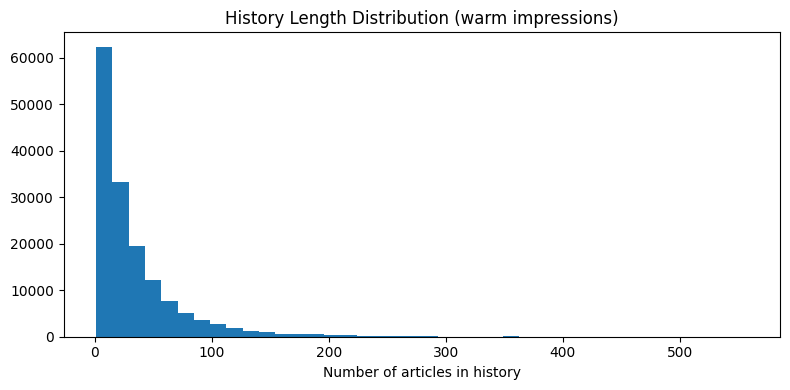

In [20]:
plt.figure(figsize=(8, 4))
plt.hist(history_lengths[history_lengths > 0], bins=40)
plt.title("History Length Distribution (warm impressions)")
plt.xlabel("Number of articles in history")
plt.tight_layout()
plt.show()

## 6. Impression and Click Analysis

In [21]:
candidates_per_impression = []
clicks_per_impression = []

for impressions in sample_behaviors["Impressions"].dropna():
    parsed = parse_impression_tokens(impressions)
    candidates_per_impression.append(len(parsed))
    clicks_per_impression.append(sum(1 for _, label in parsed if label == "1"))

candidates_per_impression = np.array(candidates_per_impression)
clicks_per_impression = np.array(clicks_per_impression)
positive_ratio = clicks_per_impression.sum() / candidates_per_impression.sum()

print(f"Avg candidates per impression: {candidates_per_impression.mean():.2f}")
print(f"Avg clicks per impression:     {clicks_per_impression.mean():.2f}")
print(f"Overall positive label ratio:  {positive_ratio:.2%}")

Avg candidates per impression: 37.11
Avg clicks per impression:     1.51
Overall positive label ratio:  4.07%


**Why PR-AUC matters here:** with an overall positive rate around the value printed
above (typically well under 10% for MIND), a classifier can achieve a deceptively high
ROC-AUC while still ranking positives poorly among the much larger negative class.
**PR-AUC (average precision)** is more sensitive to this imbalance and is reported
alongside ROC-AUC for the trained click ranker in Notebook 02/03.

## 7. Train/Dev Split Verification

In [22]:
dev_news = load_news(DEV_SOURCE / "news.tsv")
dev_behaviors = load_behaviors(DEV_SOURCE / "behaviors.tsv")

print("TRAIN_SOURCE:", TRAIN_SOURCE)
print("DEV_SOURCE:  ", DEV_SOURCE)
assert TRAIN_SOURCE != DEV_SOURCE

assert list(dev_news.columns) == list(news.columns), "Dev news schema does not match train news schema."
assert list(dev_behaviors.columns) == list(behaviors.columns), "Dev behaviors schema does not match train schema."

train_news_ids = set(news["NewsID"])
dev_news_ids = set(dev_news["NewsID"])
overlap = train_news_ids & dev_news_ids

print()
print("Train news shape:     ", news.shape)
print("Dev news shape:       ", dev_news.shape)
print("Train behaviors shape:", behaviors.shape)
print("Dev behaviors shape:  ", dev_behaviors.shape)
print(f"NewsID overlap between train and dev: {len(overlap):,} "
      f"({len(overlap) / len(dev_news_ids):.1%} of dev NewsIDs also appear in train)")
print("\nTrain and dev are confirmed distinct, same-schema datasets — never combined.")


2026-07-13 19:55:39 | INFO     | news_recommender | Loaded news file: /kaggle/input/datasets/timepassforme01/mindsmall-dev/MINDsmall_dev/news.tsv -> (42416, 8)
2026-07-13 19:55:40 | INFO     | news_recommender | Loaded behaviors file: /kaggle/input/datasets/timepassforme01/mindsmall-dev/MINDsmall_dev/behaviors.tsv -> (73152, 5)


TRAIN_SOURCE: /kaggle/input/datasets/timepassforme01/mindsmall-train/MINDsmall_train
DEV_SOURCE:   /kaggle/input/datasets/timepassforme01/mindsmall-dev/MINDsmall_dev

Train news shape:      (51282, 8)
Dev news shape:        (42416, 8)
Train behaviors shape: (156965, 5)
Dev behaviors shape:   (73152, 5)
NewsID overlap between train and dev: 28,460 (67.1% of dev NewsIDs also appear in train)

Train and dev are confirmed distinct, same-schema datasets — never combined.


**Observation:** Train and dev share the same schema but are distinct files with
distinct (though overlapping) NewsID universes — this is exactly why the project builds
**separate** embeddings, NewsID mappings, and FAISS indexes for dev rather than reusing
the train ones.

## 8. EDA Summary

**What this EDA motivates for the rest of the pipeline:**

- **Semantic embeddings over TF-IDF** — titles and especially abstracts are often short
  or missing (Section 4), so a pretrained sentence encoder that captures meaning beyond
  exact word overlap is more robust than sparse lexical features.
- **FAISS retrieval** — with tens of thousands of articles, a brute-force encoder call
  per candidate is wasteful; a similarity index makes candidate generation fast.
- **Personalized user profiles from history** — most impressions have usable history
  (Section 5), so averaging clicked-article embeddings is a reasonable, cheap
  personalization signal.
- **Popularity fallback for cold-start** — a non-trivial share of impressions have no
  history (Section 5), so a content-similarity-only approach would fail for them; a
  popularity-based fallback covers this gap.
- **Trained click ranking, not just hand-picked weights** — the class imbalance and
  moderate positive rate seen in Section 6 are exactly the conditions where a supervised
  ranker (Logistic Regression / LightGBM) trained on real click labels can out-perform
  fixed similarity+popularity weights.
- **PR-AUC alongside ROC-AUC** — given the class imbalance quantified in Section 6,
  ROC-AUC alone would overstate how well a model separates true clicks from the (much
  larger) non-click class; PR-AUC is the more honest metric here.

Proceed to `02_Model_Development.ipynb`, which trains on `MINDsmall_train` only.